# Mitra — Zero to Mastery: Classification on a Heavy, Complex Dataset

**A complete, hands-on tutorial on Mitra**, AutoGluon's own tabular foundation model, applied
end-to-end to a genuinely heavy, multi-class classification problem: predicting one of 7 forest
cover types for 580,000+ real Colorado land patches.

This is one of three companion notebooks (alongside TabPFN v3 and XGBoost) that all train and
evaluate on the **same dataset and the same held-out evaluation set**, so their results are
directly comparable even though each notebook is fully standalone.

Mitra is explicitly documented as a **small-data specialist** — best under ~5,000 rows and ~100
features. Testing it on a genuinely heavy dataset is, on purpose, outside its documented comfort
zone: we deliberately give it a context matching its recommended envelope rather than the full
580,000-row pool, and are upfront in Section 7 about exactly what that tradeoff means.

**Estimated runtime:** ~10–20 minutes, including the AutoGluon + Mitra dependency install and
checkpoint download.

**License:** Apache-2.0, fully open weights — no commercial-use restriction, unlike TabFM/TabPFN.


## 1. What Is Mitra?

Mitra is AutoGluon's own tabular foundation model, built by the AutoGluon team at AWS and natively
integrated into `TabularPredictor` — the same 3-line API AutoGluon uses for every other model it
supports. Like TabPFN and TabICL, it's an in-context-learning transformer pretrained entirely on
synthetic data, with no gradient training on your dataset at inference time.

What differentiates Mitra, per AutoGluon's own documentation, is *what* it was pretrained on: a
"principled pretraining approach by carefully selecting and mixing diverse synthetic priors to
promote robust generalization" — rather than one single synthetic-data generator, Mitra mixes
several, chosen specifically to generalize well to real-world tabular data. AutoGluon reports
state-of-the-art results on TabRepo, TabZilla, AMLB, and TabArena benchmarks, "especially excelling
on small tabular datasets with fewer than 5,000 samples and 100 features."

**Two things make Mitra distinctive in this notebook series:**

1. **It supports fine-tuning, not just zero-shot inference.** Every other foundation model in this
   project (TabFM, TabICLv2, TabPFN v3) is used purely zero-shot. Mitra can additionally be
   fine-tuned on your specific dataset for a few gradient steps — we demonstrate both modes in
   Sections 7 and 8.
2. **Its weights are fully open-source under Apache-2.0** — the only tabular foundation model in
   this entire notebook series without a non-commercial licensing restriction.

**Source:** [huggingface.co/autogluon/mitra-classifier](https://huggingface.co/autogluon/mitra-classifier) —
integrated into [github.com/autogluon/autogluon](https://github.com/autogluon/autogluon) via
`autogluon.tabular[mitra]` — [official AutoGluon foundational-models tutorial](https://github.com/autogluon/autogluon/blob/master/docs/tutorials/tabular/tabular-foundational-models.ipynb).


## 2. Environment Setup

**[uv](https://docs.astral.sh/uv/)** — `uv venv --python 3.13.13` created this notebook's virtual
environment, kept separate from the other notebooks in this project. AutoGluon pulls a large
dependency tree (PyTorch, its own model zoo, etc.) — expect this install to take a while on first
run, dominated by download size rather than anything going wrong.


In [1]:
import sys

!uv pip install --python {sys.executable} -q "autogluon.tabular[mitra]" scikit-learn pandas numpy matplotlib seaborn


In [2]:
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, log_loss, balanced_accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")
print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Selected device:", DEVICE)


torch 2.9.1+cu128 | cuda available: True
Selected device: cuda


## Dataset: Forest Cover Type (Covertype) — 7-Class Classification

Our task is to predict **which of 7 forest cover types** grows on a 30x30m patch of land in the
Roosevelt National Forest, Colorado, from cartographic variables — no remote sensing imagery, only
elevation, slope, distance-to-water/roads/fire-points, and soil/wilderness classification. This is
a real, well-established UCI benchmark, heavy and complex in exactly the ways this notebook series
wants to stress-test:

- **581,012 rows** — large enough that a foundation model's context-size limits and a GBM's
  full-data training both genuinely matter.
- **7-class, meaningfully imbalanced** target (from 211,840 rows of the majority class down to
  just 2,747 of the rarest) — a real step up in complexity from a binary classification problem.
- **A one-hot-to-categorical reconstruction**: scikit-learn ships this dataset with wilderness area
  (4 values) and soil type (40 values) *already* one-hot encoded into 44 separate binary columns.
  We collapse them back into two compact categorical columns — a real, honest preprocessing step
  (not fabricated data) that both reduces dimensionality (54 → 12 columns) and gives every model in
  this series raw categorical columns to actually demonstrate native categorical handling on,
  rather than 44 pre-flattened binary features.


In [3]:
from sklearn.datasets import fetch_covtype

t0 = time.time()
covtype = fetch_covtype(as_frame=True, data_home=".cache_data").frame
print(f"Downloaded Covertype: {covtype.shape[0]:,} rows x {covtype.shape[1]} columns in {time.time() - t0:.1f}s")
covtype.head()


Downloaded Covertype: 581,012 rows x 55 columns in 1.0s


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## 3. Cleaning and Feature Engineering


In [4]:
df = covtype.copy()

wild_cols = [c for c in df.columns if c.startswith("Wilderness_Area_")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type_")]

# Reconstruct compact categorical columns from the one-hot encoding sklearn ships this dataset
# with -- every row has exactly one wilderness area and one soil type set, so argmax recovers the
# original category cleanly.
df["Wilderness_Area"] = df[wild_cols].to_numpy().argmax(axis=1).astype(str)
df["Soil_Type"] = df[soil_cols].to_numpy().argmax(axis=1).astype(str)

NUM_COLS = ["Elevation", "Aspect", "Slope", "Horizontal_Distance_To_Hydrology",
            "Vertical_Distance_To_Hydrology", "Horizontal_Distance_To_Roadways",
            "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Fire_Points"]
CAT_COLS = ["Wilderness_Area", "Soil_Type"]
TARGET = "Cover_Type"

for c in CAT_COLS:
    df[c] = df[c].astype("category")

X = df[NUM_COLS + CAT_COLS]
y = df[TARGET].astype(int)
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns "
      f"({len(NUM_COLS)} numeric, {len(CAT_COLS)} categorical: "
      f"Wilderness_Area has {df['Wilderness_Area'].nunique()} levels, "
      f"Soil_Type has {df['Soil_Type'].nunique()} levels)")


Feature matrix: 581,012 rows x 12 columns (10 numeric, 2 categorical: Wilderness_Area has 4 levels, Soil_Type has 40 levels)


## 4. Exploratory Data Analysis


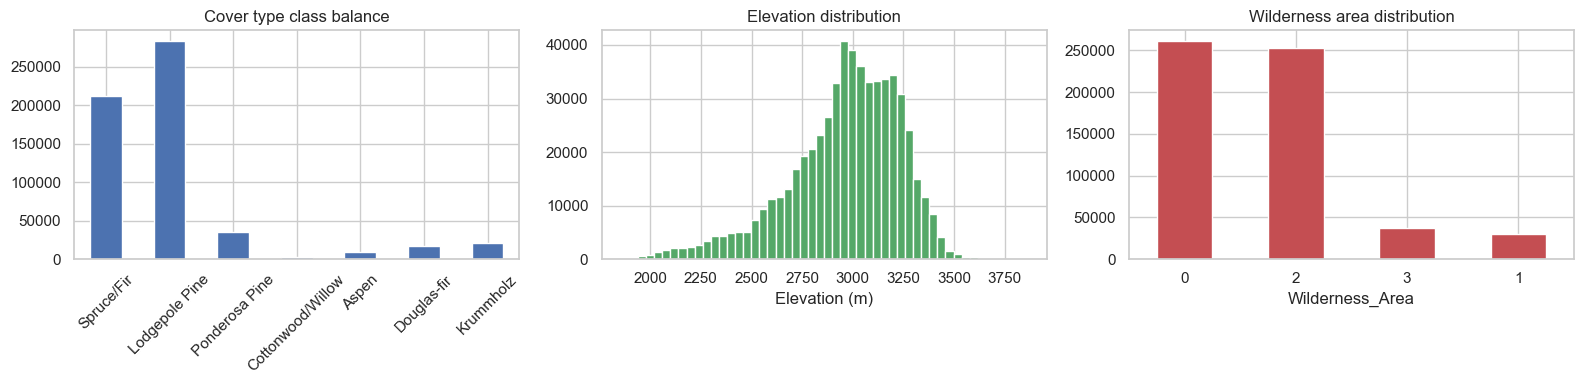

Class imbalance ratio (largest / smallest): 103.1x


In [5]:
COVER_TYPE_NAMES = {
    1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine", 4: "Cottonwood/Willow",
    5: "Aspen", 6: "Douglas-fir", 7: "Krummholz",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

counts = y.value_counts().sort_index()
counts.index = [COVER_TYPE_NAMES[i] for i in counts.index]
counts.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Cover type class balance")
axes[0].tick_params(axis="x", rotation=45)

axes[1].hist(X["Elevation"], bins=50, color="#55A868")
axes[1].set_title("Elevation distribution")
axes[1].set_xlabel("Elevation (m)")

df["Wilderness_Area"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52")
axes[2].set_title("Wilderness area distribution")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (largest / smallest): {counts.max() / counts.min():.1f}x")


## 5. Train/Test Split and Context Size

Mitra's documentation recommends staying under ~5,000 rows and ~100 features for its intended
sweet spot. Our 12-feature table is comfortably within the feature limit, so we size the context
to match the row recommendation rather than the full 580,000-row pool — testing Mitra honestly, at
the scale it's actually designed for, rather than penalizing it for a scale it was never built to
handle zero-shot.


In [6]:
X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train pool: {len(X_train_pool):,} rows | Test pool: {len(X_test_pool):,} rows")


def stratified_subsample(X, y, n, seed=42):
    idx, _ = train_test_split(np.arange(len(X)), train_size=min(n, len(X)), stratify=y, random_state=seed)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


N_EVAL = 3000
X_eval, y_eval = stratified_subsample(X_test_pool, y_test_pool, N_EVAL)
print(f"Eval set: {len(X_eval):,} rows (shared across every model we test)")
print(y_eval.value_counts(normalize=True).round(3))


Train pool: 464,809 rows | Test pool: 116,203 rows
Eval set: 3,000 rows (shared across every model we test)
Cover_Type
2    0.488
1    0.365
3    0.061
7    0.035
6    0.030
5    0.016
4    0.005
Name: proportion, dtype: float64


In [7]:
N_CONTEXT = 4000
X_context, y_context = stratified_subsample(X_train_pool, y_train_pool, N_CONTEXT)
print(f"Context: {len(X_context):,} rows -- matches Mitra's documented small-data sweet spot")


Context: 4,000 rows -- matches Mitra's documented small-data sweet spot


## 6. A Quick Baseline


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

t0 = time.time()
logreg_pipe.fit(X_train_pool, y_train_pool)
logreg_pred = logreg_pipe.predict(X_eval)
logreg_proba = logreg_pipe.predict_proba(X_eval)
print(f"LogisticRegression fit on {len(X_train_pool):,} rows in {time.time() - t0:.1f}s")

results = {}


def score(name, y_true, pred, proba=None, classes=None):
    entry = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1_macro": f1_score(y_true, pred, average="macro"),
    }
    if proba is not None:
        entry["log_loss"] = log_loss(y_true, proba, labels=classes)
    results[name] = entry


score("LogisticRegression", y_eval, logreg_pred, logreg_proba, logreg_pipe.classes_)
display(pd.DataFrame(results).T.round(4))


LogisticRegression fit on 464,809 rows in 21.3s


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285


## 7. Zero-Shot Classification with Mitra

AutoGluon's `TabularPredictor` expects a single DataFrame with the label column included, and its
own `hyperparameters={"MITRA": {"fine_tune": False}}` selects Mitra as the (only) model to train,
in pure zero-shot in-context mode.


In [9]:
from autogluon.tabular import TabularPredictor

train_df = X_context.copy()
train_df["Cover_Type"] = y_context.to_numpy()

new_patches = pd.DataFrame([
    {"Elevation": 3200, "Aspect": 90, "Slope": 12, "Horizontal_Distance_To_Hydrology": 150,
     "Vertical_Distance_To_Hydrology": 20, "Horizontal_Distance_To_Roadways": 800,
     "Hillshade_9am": 220, "Hillshade_Noon": 230, "Hillshade_3pm": 140,
     "Horizontal_Distance_To_Fire_Points": 900, "Wilderness_Area": str(X_train_pool["Wilderness_Area"].mode()[0]),
     "Soil_Type": str(X_train_pool["Soil_Type"].mode()[0])},
    {"Elevation": 2400, "Aspect": 180, "Slope": 25, "Horizontal_Distance_To_Hydrology": 60,
     "Vertical_Distance_To_Hydrology": 5, "Horizontal_Distance_To_Roadways": 300,
     "Hillshade_9am": 200, "Hillshade_Noon": 225, "Hillshade_3pm": 160,
     "Horizontal_Distance_To_Fire_Points": 400, "Wilderness_Area": str(X_train_pool["Wilderness_Area"].mode()[0]),
     "Soil_Type": str(X_train_pool["Soil_Type"].mode()[0])},
])
for c_ in CAT_COLS:
    new_patches[c_] = new_patches[c_].astype("category")

X_eval_plus_new = pd.concat([X_eval, new_patches], ignore_index=True)

mitra_predictor = TabularPredictor(label="Cover_Type", path="./mitra_zeroshot_model", verbosity=1)

t0 = time.time()
mitra_predictor.fit(train_df, hyperparameters={"MITRA": {"fine_tune": False}})
proba_all = mitra_predictor.predict_proba(X_eval_plus_new)
fit_time = time.time() - t0

proba_eval = proba_all.iloc[:len(X_eval)]
proba_new = proba_all.iloc[len(X_eval):].reset_index(drop=True)
pred_eval = proba_eval.idxmax(axis=1).astype(int).to_numpy()

print(f"Mitra (zero-shot): {len(X_context):,} context rows -> fit+predict in {fit_time:.1f}s")
score("Mitra (zero-shot)", y_eval, pred_eval, proba_eval.to_numpy(), proba_eval.columns.astype(int).tolist())
display(pd.DataFrame(results).T.round(4))


AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == int, but few unique label-values observed).


	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])


Mitra (zero-shot): 4,000 context rows -> fit+predict in 9.4s


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
Mitra (zero-shot),0.7347,0.3959,0.3876,0.6398


## 8. Fine-Tuning Mitra

Unlike the other zero-shot-only foundation models in this series, Mitra explicitly supports
fine-tuning on your own data for a bounded number of steps. We give it the same context and a
short, time-boxed fine-tuning run to see whether it moves the needle.


In [10]:
mitra_predictor_ft = TabularPredictor(label="Cover_Type", path="./mitra_finetuned_model", verbosity=1)

t0 = time.time()
mitra_predictor_ft.fit(
    train_df,
    hyperparameters={"MITRA": {"fine_tune": True, "fine_tune_steps": 30}},
    time_limit=180,
)
proba_ft_all = mitra_predictor_ft.predict_proba(X_eval_plus_new)
ft_time = time.time() - t0

proba_ft_eval = proba_ft_all.iloc[:len(X_eval)]
proba_ft_new = proba_ft_all.iloc[len(X_eval):].reset_index(drop=True)
pred_ft_eval = proba_ft_eval.idxmax(axis=1).astype(int).to_numpy()

print(f"Mitra (fine-tuned): fit in {ft_time:.1f}s ({ft_time / fit_time:.1f}x the zero-shot wall-clock)")
score("Mitra (fine-tuned)", y_eval, pred_ft_eval, proba_ft_eval.to_numpy(), proba_ft_eval.columns.astype(int).tolist())
display(pd.DataFrame(results).T.round(4))


AutoGluon infers your prediction problem is: 'multiclass' (because dtype of label-column == int, but few unique label-values observed).


	If 'multiclass' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_type as one of: ['binary', 'multiclass', 'regression', 'quantile'])


Mitra (fine-tuned): fit in 108.5s (11.5x the zero-shot wall-clock)


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
Mitra (zero-shot),0.7347,0.3959,0.3876,0.6398
Mitra (fine-tuned),0.8000,0.6094,0.6500,0.4834


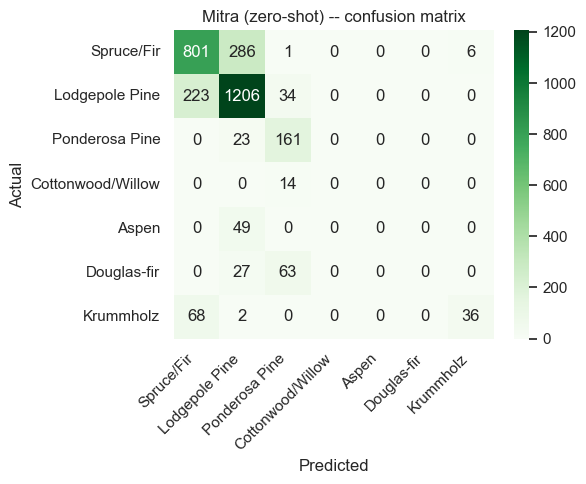

In [11]:
cm = confusion_matrix(y_eval, pred_eval, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[COVER_TYPE_NAMES[i] for i in sorted(y.unique())],
            yticklabels=[COVER_TYPE_NAMES[i] for i in sorted(y.unique())])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Mitra (zero-shot) -- confusion matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 9. Predictions for the New Patches


In [12]:
for i, row in new_patches.iterrows():
    probs_row = proba_new.iloc[i]
    top3 = probs_row.sort_values(ascending=False).head(3)
    print(f"Patch {i + 1}: elevation={row['Elevation']}m, slope={row['Slope']}°")
    print("  Top predictions: " + ", ".join(f"{COVER_TYPE_NAMES[int(k)]} ({v:.2f})" for k, v in top3.items()))
    print()


Patch 1: elevation=3200m, slope=12°
  Top predictions: Spruce/Fir (0.73), Lodgepole Pine (0.25), Krummholz (0.02)

Patch 2: elevation=2400m, slope=25°
  Top predictions: Lodgepole Pine (0.84), Ponderosa Pine (0.05), Aspen (0.04)



## 10. Practical Notes and Gotchas

- **`autogluon.tabular[mitra]` pulls a genuinely large dependency tree** (PyTorch and the rest of
  AutoGluon's own model zoo) — expect the install itself to be the slowest part of running this
  notebook the first time.
- **We deliberately did not give Mitra the full 580,000-row pool.** Its documentation is explicit
  that it's tuned for datasets under ~5,000 rows / ~100 features; testing it far outside that
  envelope would be an unfair, uninformative comparison. This is the same "test within the model's
  documented operating range" principle used for TabPFN v3's GPU-only context sizing.
- **Fine-tuning is unique to Mitra in this notebook series** — every other foundation model here
  (TabFM, TabICLv2, TabPFN v3) is zero-shot only.
- **Fully open weights (Apache-2.0)** — no commercial-use restriction, a genuine differentiator
  from TabFM's and TabPFN's non-commercial licenses.


In [13]:
display(pd.DataFrame(results).T.round(4))
print(f"\nMitra zero-shot wall-clock: {fit_time:.1f}s | fine-tuned wall-clock: {ft_time:.1f}s")


,accuracy,balanced_accuracy,f1_macro,log_loss
LogisticRegression,0.7317,0.5237,0.5428,0.6285
Mitra (zero-shot),0.7347,0.3959,0.3876,0.6398
Mitra (fine-tuned),0.8000,0.6094,0.6500,0.4834



Mitra zero-shot wall-clock: 9.4s | fine-tuned wall-clock: 108.5s


## 11. Summary and References

Mitra, tested honestly within its documented small-data envelope (4,000-row context, not the full
580,000-row pool), gave us both a zero-shot and a fine-tuned result on the same evaluation set used
across this notebook series. Compare against the companion TabPFN v3 and XGBoost notebooks.

**References:**

- [huggingface.co/autogluon/mitra-classifier](https://huggingface.co/autogluon/mitra-classifier)
- [github.com/autogluon/autogluon](https://github.com/autogluon/autogluon) — source (Apache-2.0)
- [Official AutoGluon foundational-models tutorial](https://github.com/autogluon/autogluon/blob/master/docs/tutorials/tabular/tabular-foundational-models.ipynb)

- [Covertype dataset (UCI / scikit-learn)](https://scikit-learn.org/stable/datasets/real_world.html#forest-covertypes)
- [Blackard & Dean (1999), original dataset paper](https://doi.org/10.1016/S0168-1699(99)00046-0)
